In [1]:
def get_outliers(_df, _key):
    _a = _df[_key].describe()

    _upper_space = [_a['mean']+3*_a['std'], _a['mean']+4*_a['std']]
    _lower_space = [_a['mean']-3*_a['std'], _a['mean']-4*_a['std']]

    _outlier_errors = []
    _outlier_errors.append(random.uniform(_upper_space[0], _upper_space[1]))
    _outlier_errors.append(random.uniform(_lower_space[0], _lower_space[1]))

    _flag = random.randint(0,1)

    return round(_outlier_errors[_flag],2)


def plot_distibutions(_df, _key, _n_bins):
    _variable = pd.to_numeric(_df[_key], errors='coerce').dropna()
    if _variable.empty:
        raise ValueError(f'No numeric data available for {_key}')

    _a = _variable.describe()
    _upper_space = [_a['mean'] + 3 * _a['std'], _a['mean'] + 4 * _a['std']]
    _lower_space = [_a['mean'] - 3 * _a['std'], _a['mean'] - 4 * _a['std']]

    fig, axes = plt.subplots(2, figsize=(8, 6), sharex=True)
    axes[1].hist(_variable, _n_bins, density=True, edgecolor='black')
    ax = axes[1].twinx()

    if _variable.nunique() > 1:
        _variable.plot.kde(color='red', ax=ax, bw_method=0.3)

    plot_df = pd.DataFrame({_key: _variable})
    plot_df.boxplot(column=_key, ax=axes[0], vert=False, grid=False, showmeans=True)
    axes[0].set_ylabel('')
    axes[0].set_title(f'{_key} (n={len(_variable)})')

    axes[1].axvline(x=_upper_space[0], color='r', ls='--')
    axes[1].axvline(x=_upper_space[1], color='r', ls='--')
    axes[1].axvline(x=_lower_space[0], color='r', ls='--')
    axes[1].axvline(x=_lower_space[1], color='r', ls='--')
    axes[1].set_ylabel('probability')
    ax.axis('off')
    plt.tight_layout()
    plt.show()


def normalize_run_results(run_results, temp_keys):
    results = pd.DataFrame.from_dict(run_results, orient='index')
    if results.shape[1] == 1 and results.iloc[:, 0].apply(lambda x: isinstance(x, (list, tuple, np.ndarray))).all():
        results = pd.DataFrame(results.iloc[:, 0].tolist(), index=results.index)
    results = results.apply(pd.to_numeric, errors='coerce')
    if len(results.columns) == len(temp_keys):
        results.columns = temp_keys
    else:
        results = results.reindex(columns=range(len(temp_keys)))
        results.columns = temp_keys
    results = results.dropna(axis=1, how='all')
    results.index = [f'Run {i + 1}' for i in range(len(results))]
    return results


def display_run_phik(run_idx, phi_scores, temp_keys, show_plot=True):
    run_name = f'Run {run_idx + 1}'
    run_series = pd.to_numeric(pd.Series(phi_scores, index=temp_keys), errors='coerce')
    run_table = run_series.to_frame(name='PhiK')
    print(f'{run_name} PhiK scores')
    display(run_table.round(4))

    if show_plot:
        plot_table = run_table.dropna()
        fig, ax = plt.subplots(figsize=(8, 3.2))
        ax.bar(plot_table.index, plot_table['PhiK'], color='steelblue')
        ax.set_title(f'{run_name} PhiK by parameter')
        ax.set_xlabel('Parameter')
        ax.set_ylabel('PhiK correlation')
        ax.set_ylim(0, 1)
        ax.tick_params(axis='x', rotation=45)
        plt.tight_layout()
        plt.show()

    return run_table

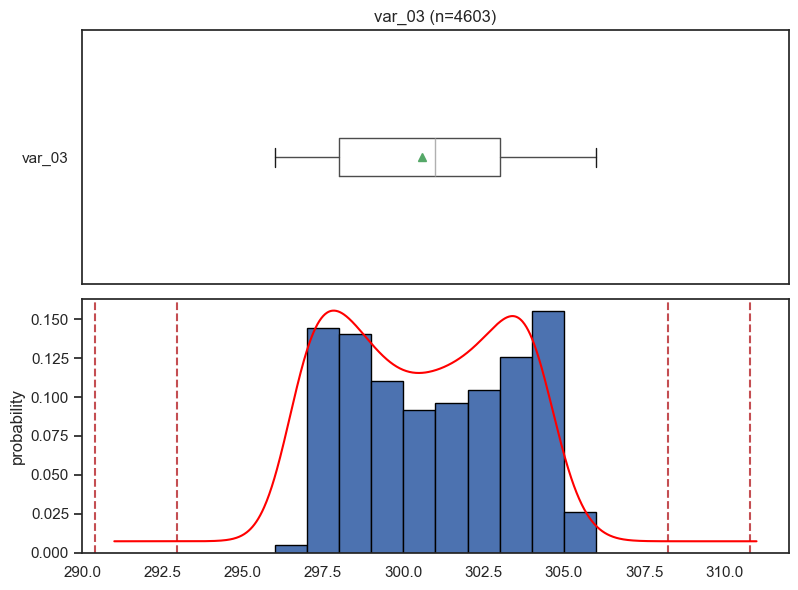

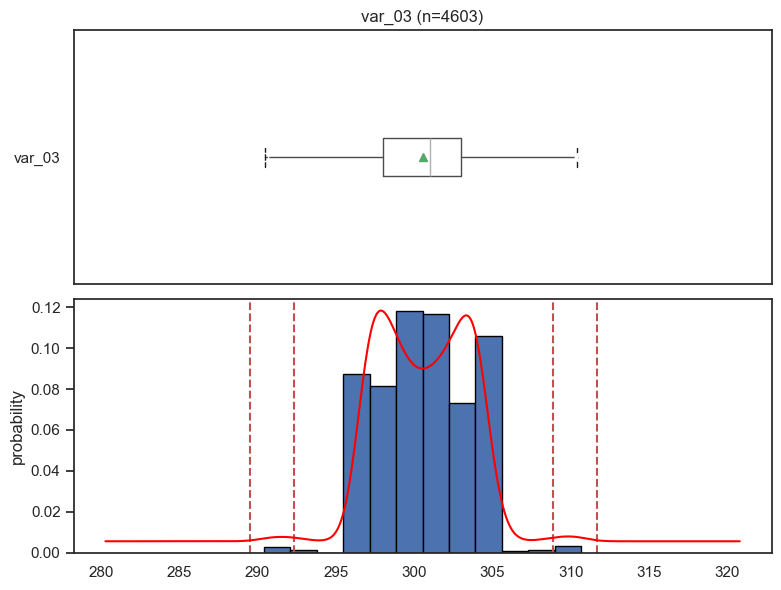

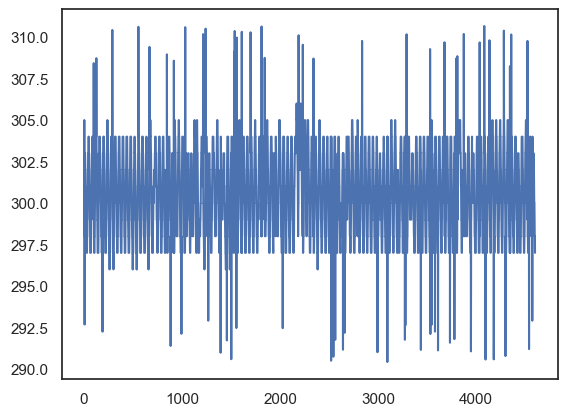

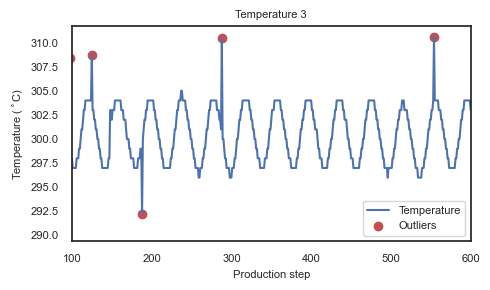

Run 1 PhiK scores


,PhiK
var_01,0.0000
var_02,0.0000
var_03,0.8100
var_04,0.0000
var_05,0.0000
var_06,0.0000
var_07,0.0000
var_08,0.0231


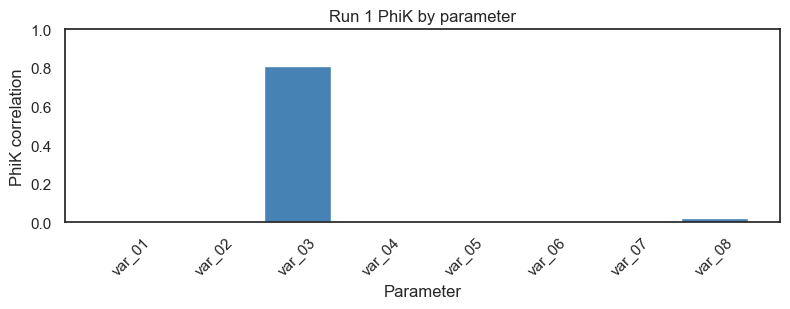

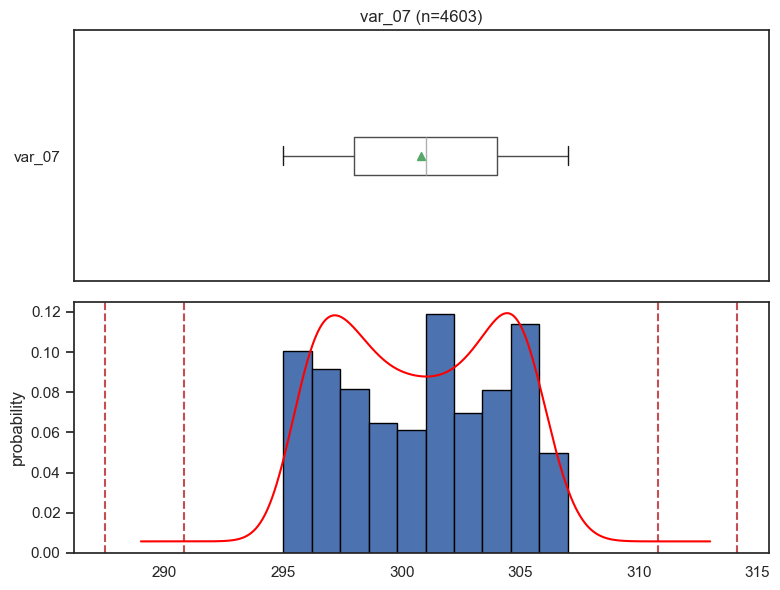

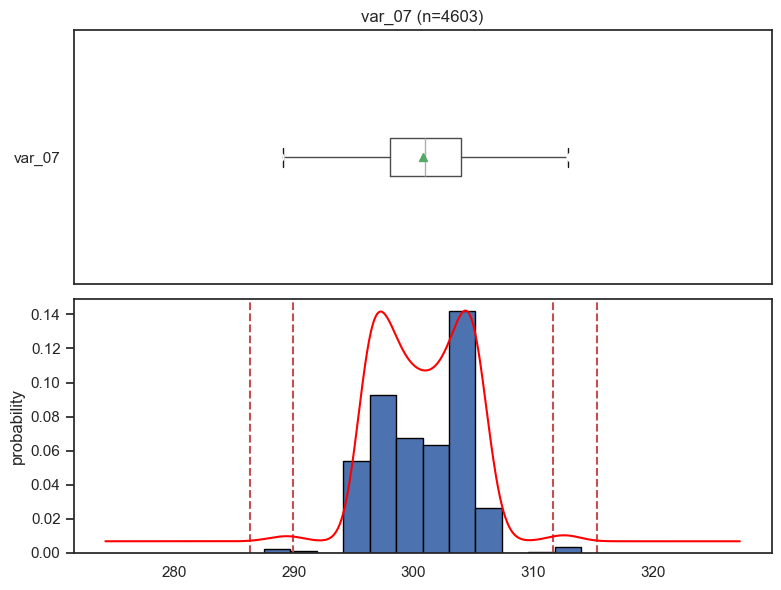

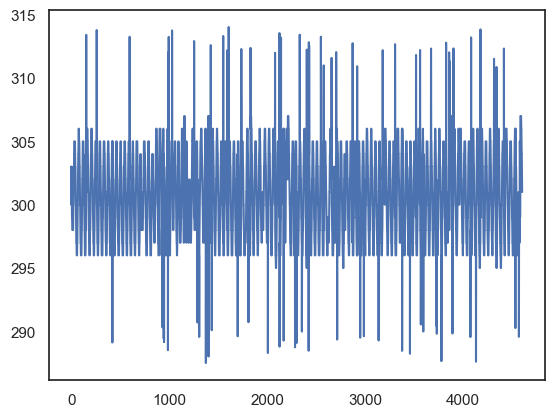

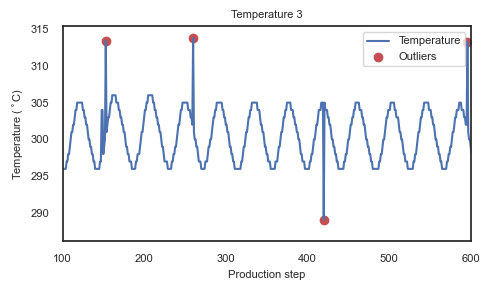

Run 2 PhiK scores


,PhiK
var_01,0.0000
var_02,0.0000
var_03,0.0238
var_04,0.0000
var_05,0.0000
var_06,0.0000
var_07,0.7990
var_08,0.0214


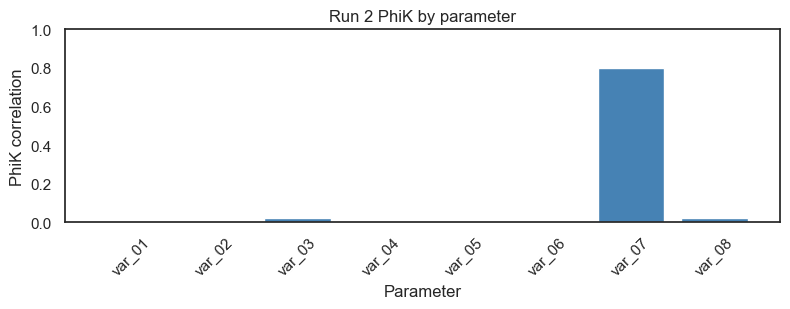

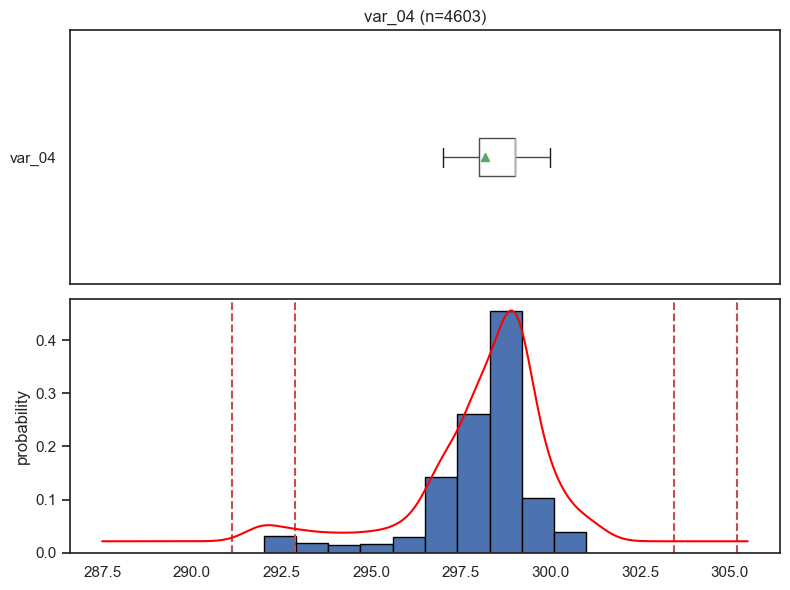

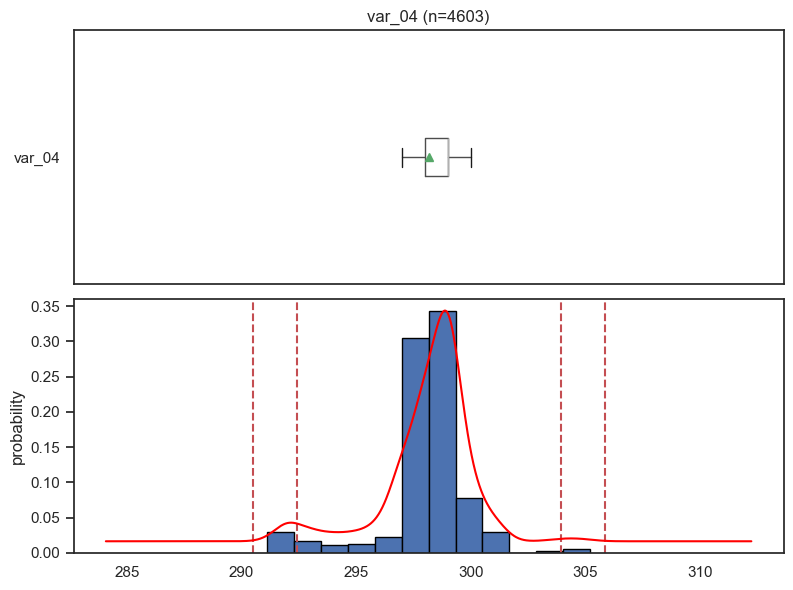

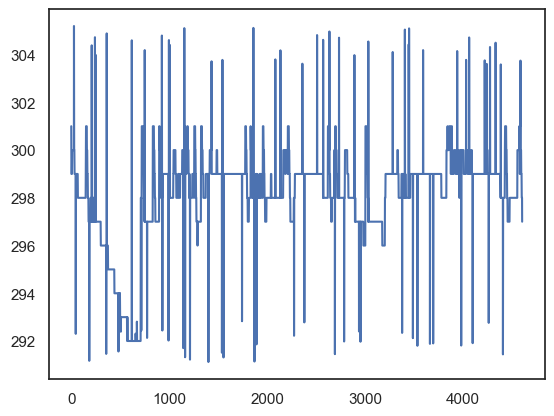

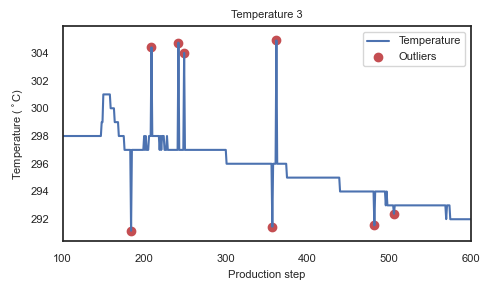

Run 3 PhiK scores


,PhiK
var_01,0.0000
var_02,0.0000
var_03,0.0000
var_04,0.7491
var_05,0.0000
var_06,0.0000
var_07,0.0578
var_08,0.0597


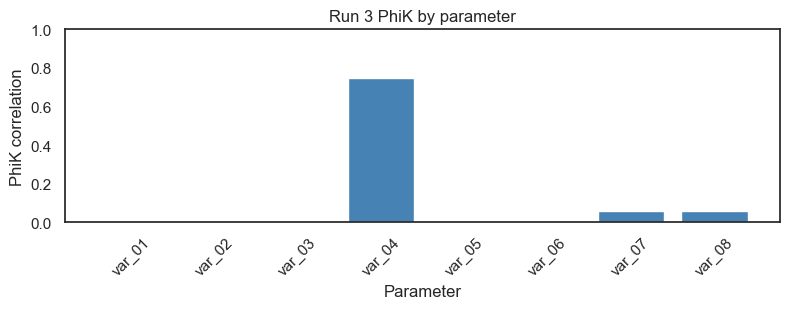

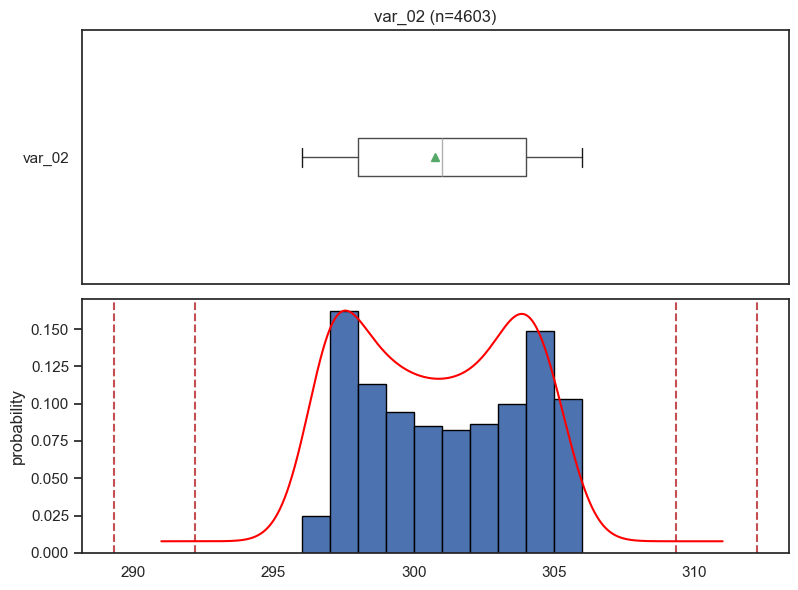

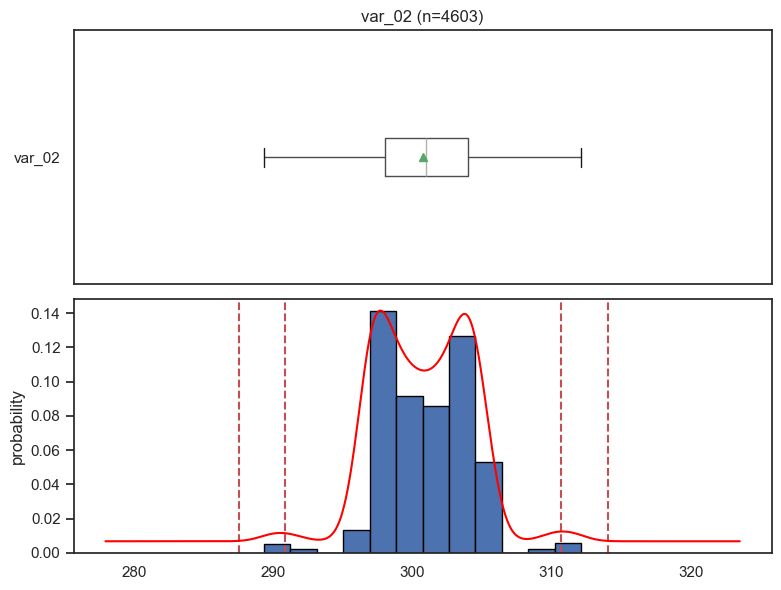

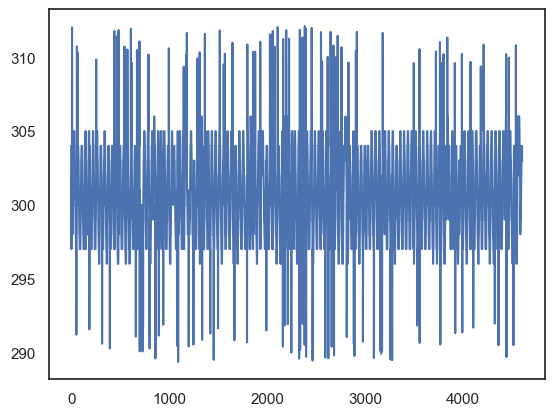

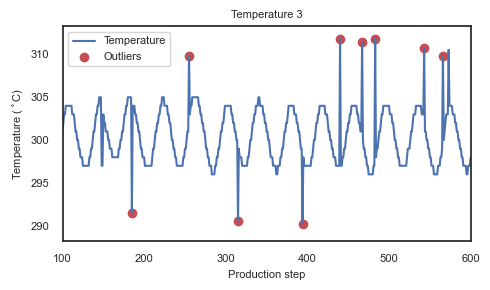

Run 4 PhiK scores


,PhiK
var_01,0.0000
var_02,0.9003
var_03,0.0000
var_04,0.0000
var_05,0.0000
var_06,0.0000
var_07,0.0000
var_08,0.0000


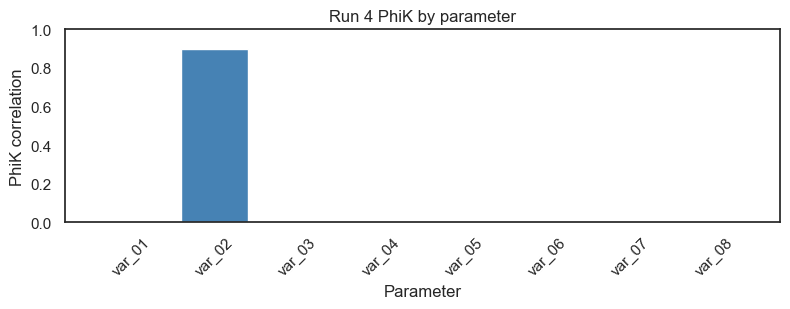

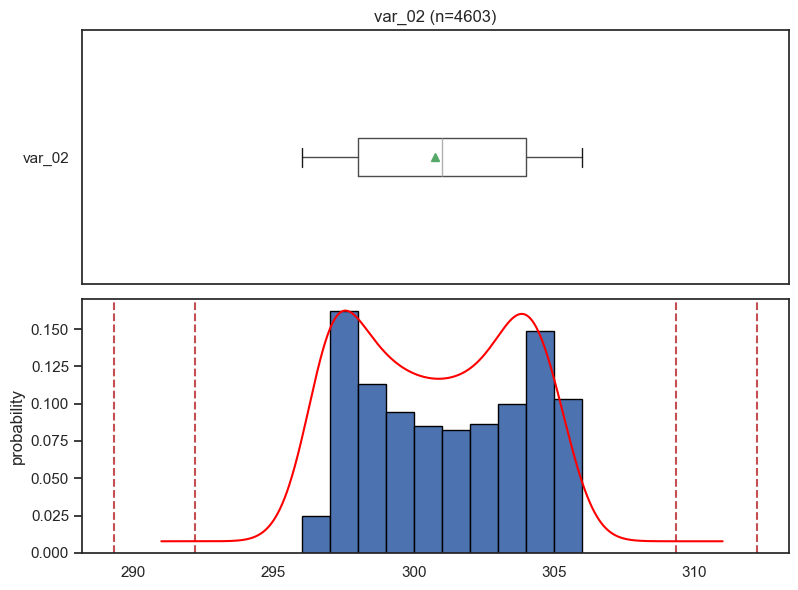

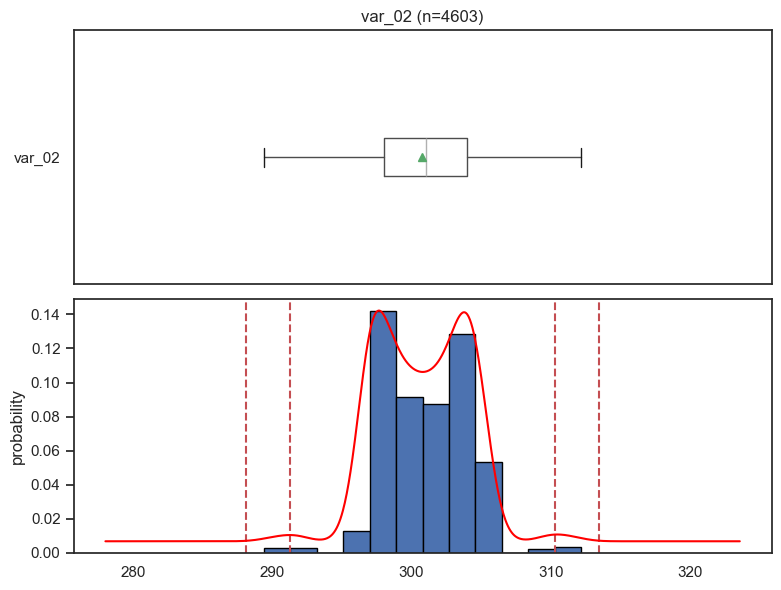

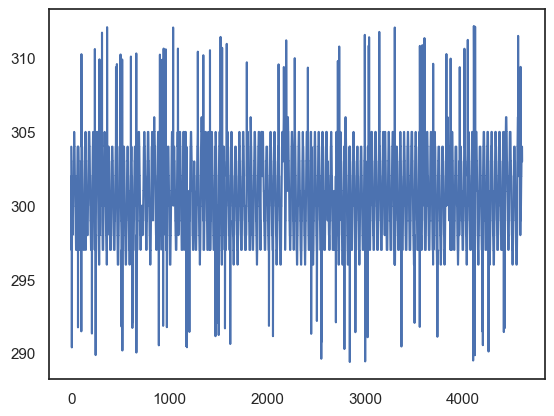

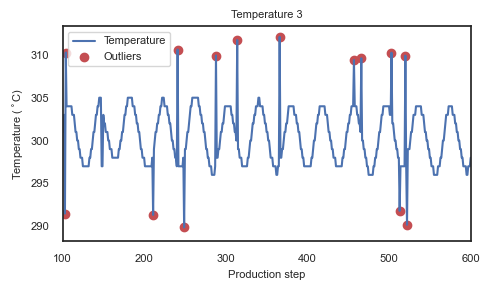

Run 5 PhiK scores


,PhiK
var_01,0.0000
var_02,0.8824
var_03,0.0000
var_04,0.0000
var_05,0.0000
var_06,0.0000
var_07,0.0000
var_08,0.0860


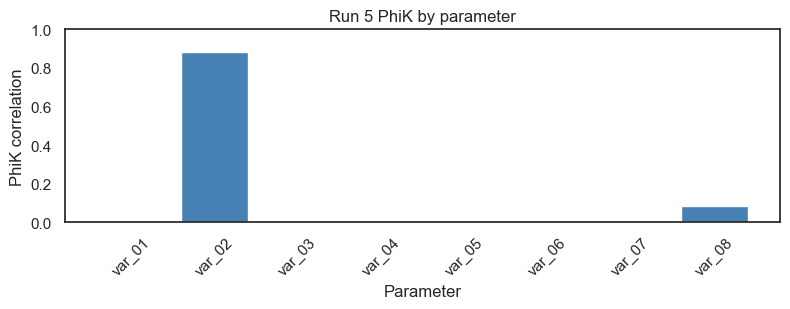

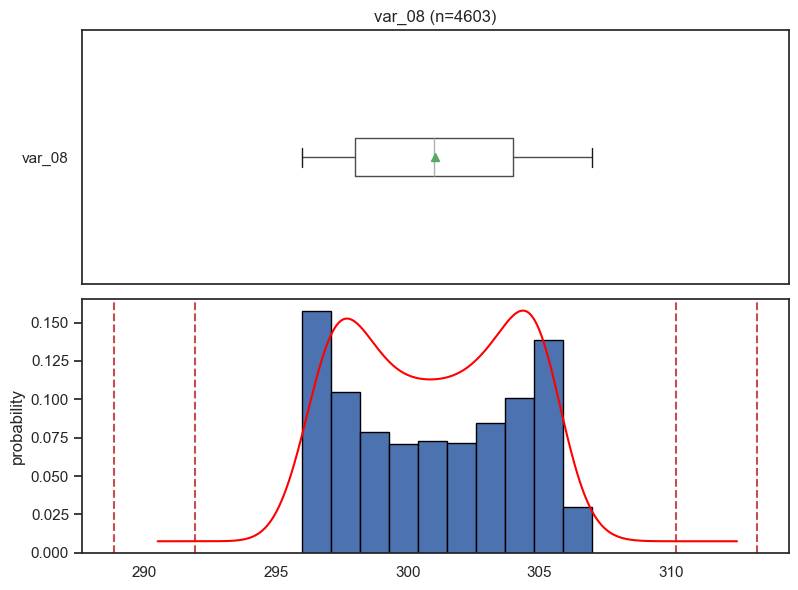

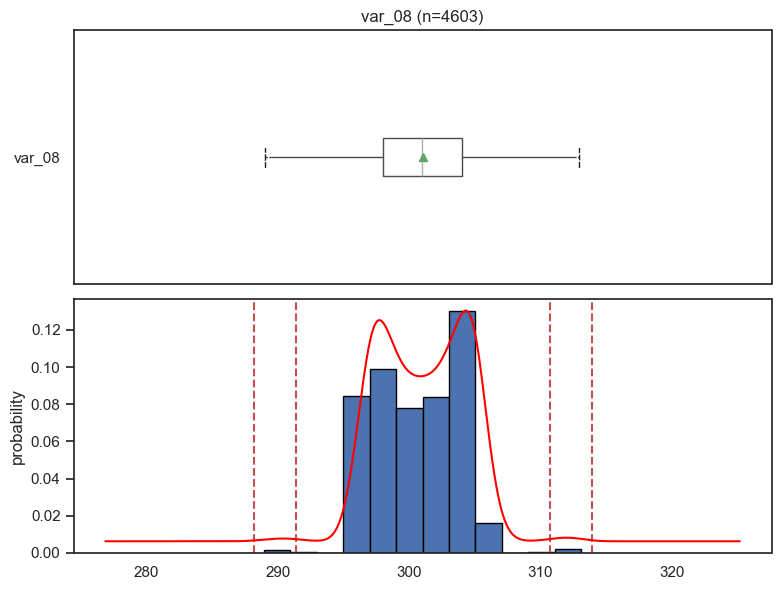

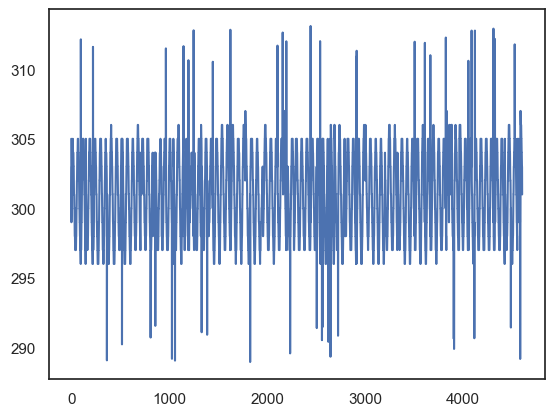

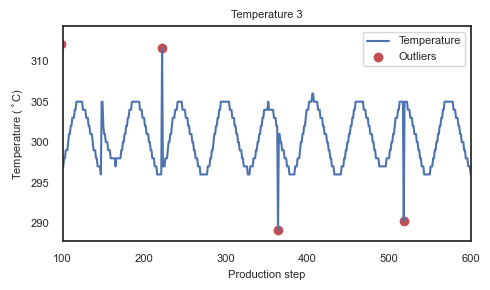

Run 6 PhiK scores


,PhiK
var_01,0.0000
var_02,0.0000
var_03,0.0000
var_04,0.0000
var_05,0.0000
var_06,0.0000
var_07,0.0000
var_08,0.7611


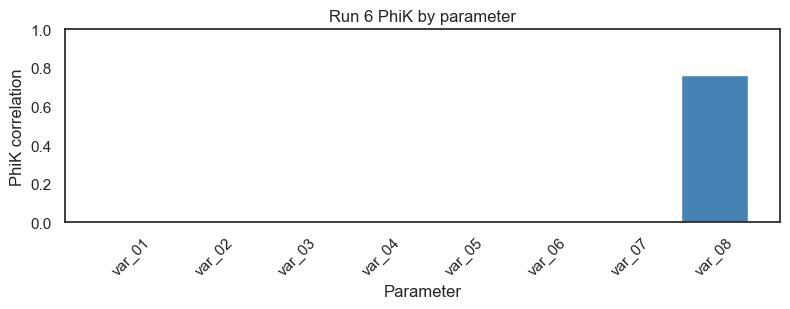

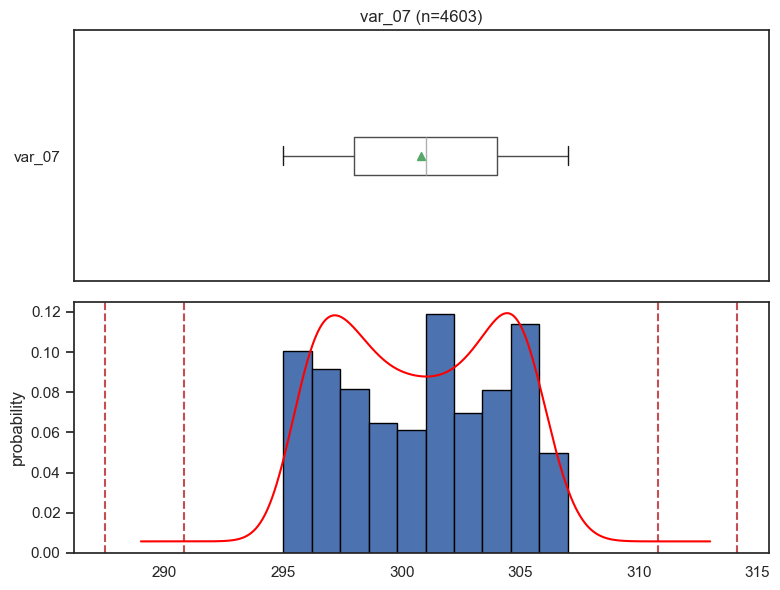

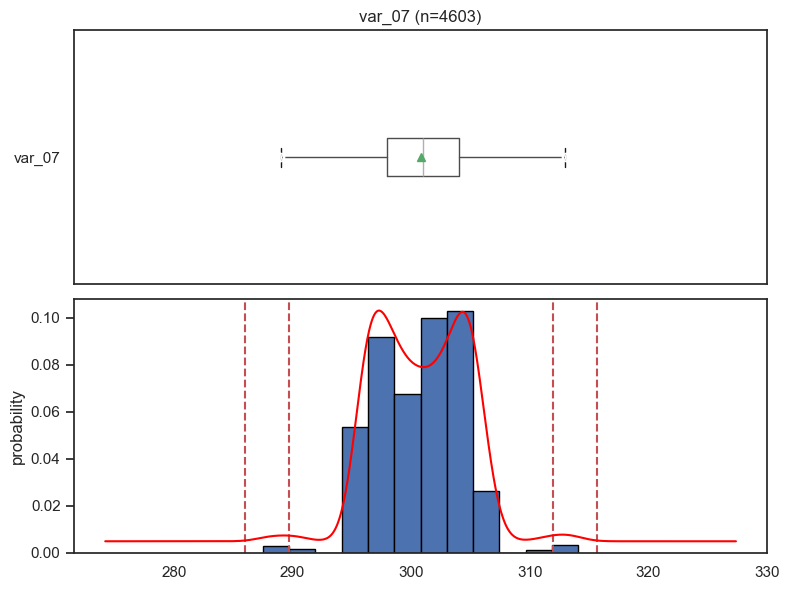

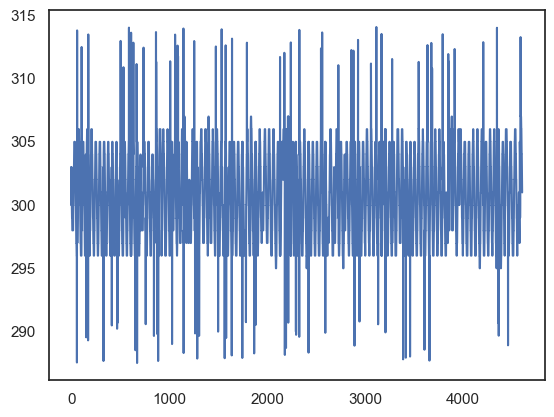

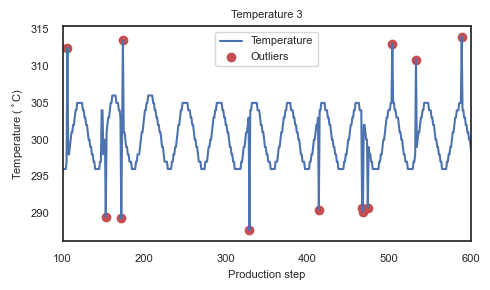

Run 7 PhiK scores


,PhiK
var_01,0.0000
var_02,0.0000
var_03,0.0000
var_04,0.0000
var_05,0.0000
var_06,0.0000
var_07,0.8865
var_08,0.0544


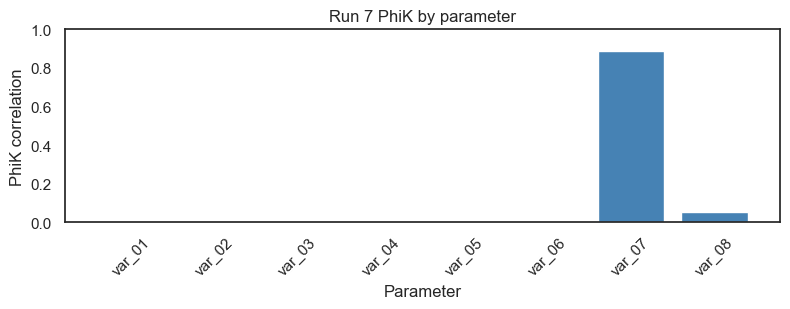

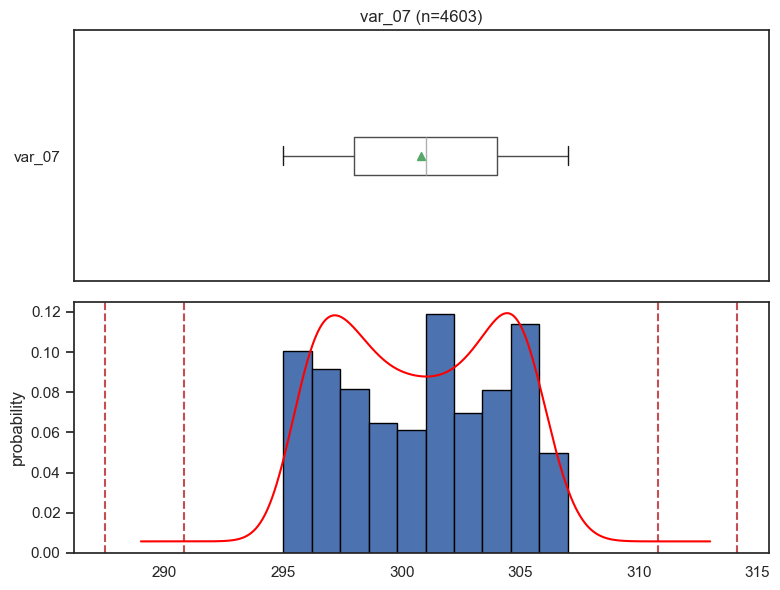

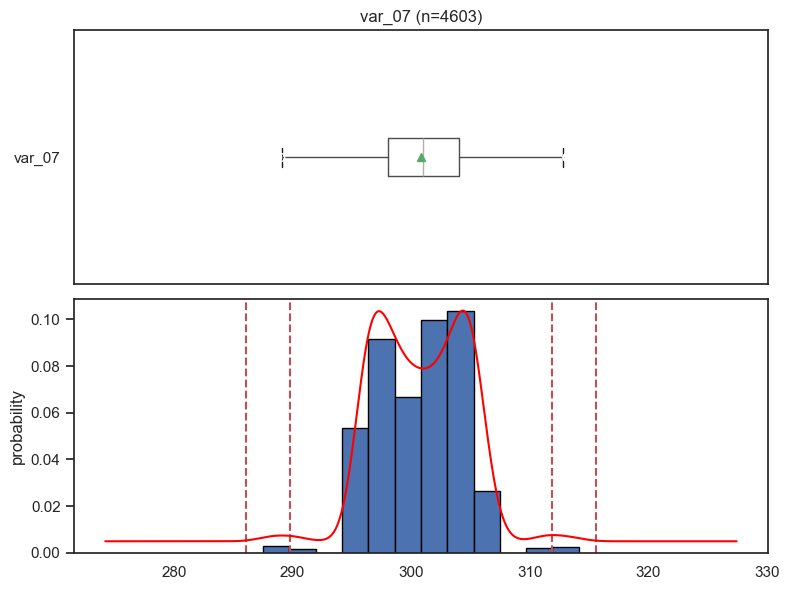

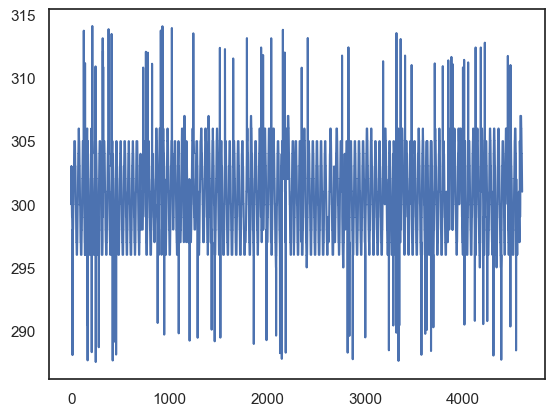

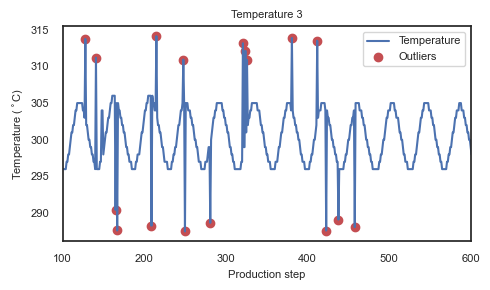

Run 8 PhiK scores


,PhiK
var_01,0.0000
var_02,0.0000
var_03,0.0000
var_04,0.0000
var_05,0.0000
var_06,0.0000
var_07,0.8782
var_08,0.0162


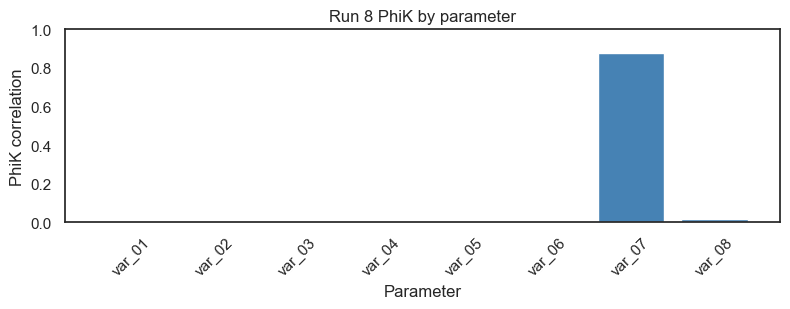

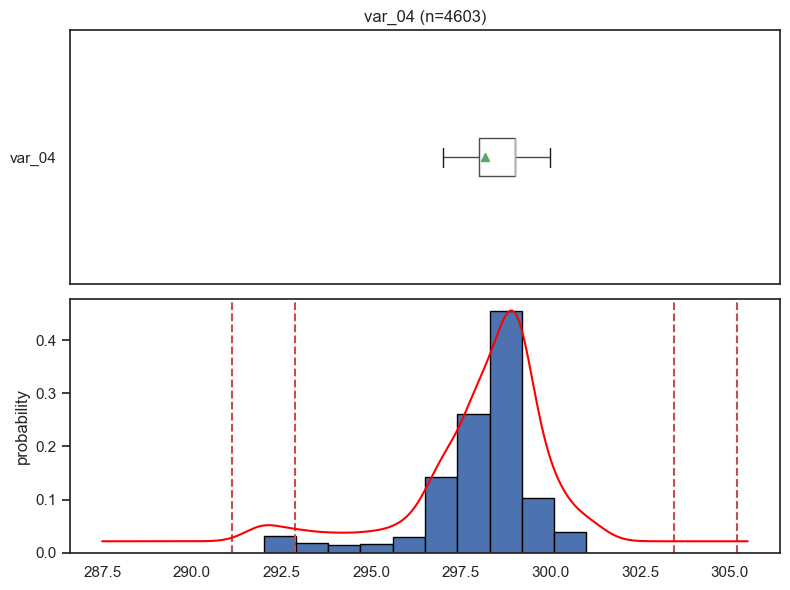

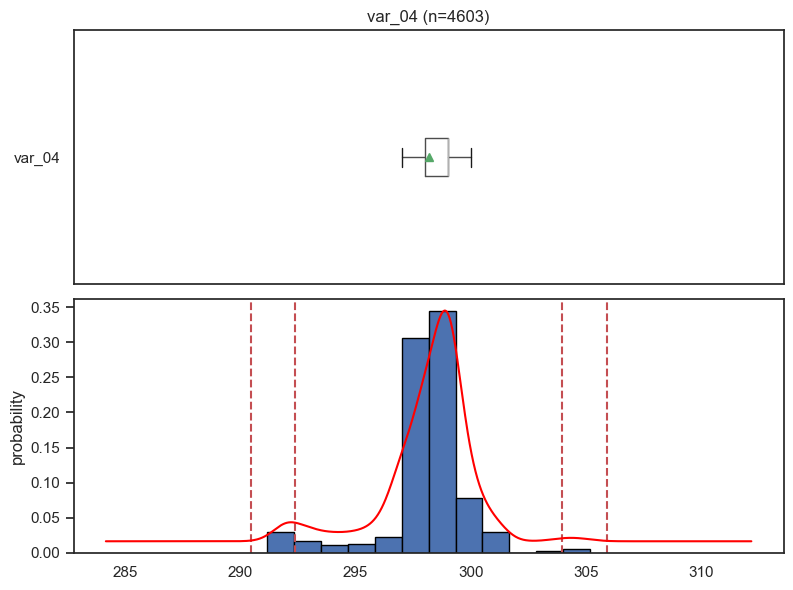

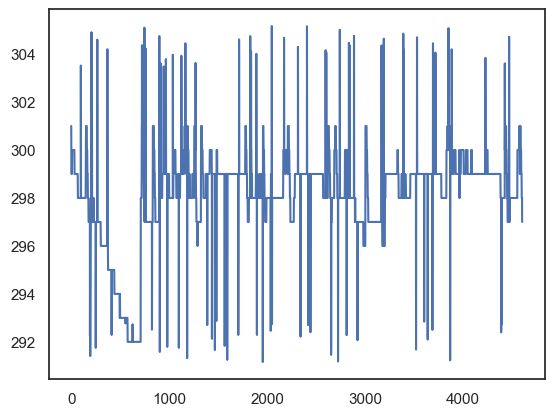

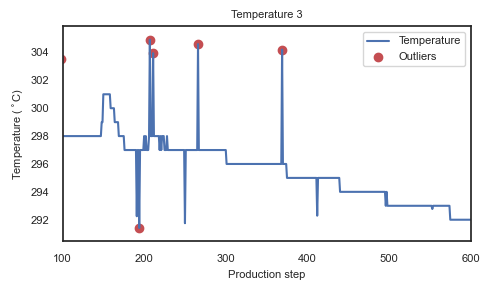

Run 9 PhiK scores


,PhiK
var_01,0.0000
var_02,0.0000
var_03,0.0000
var_04,0.7815
var_05,0.0000
var_06,0.0000
var_07,0.0129
var_08,0.0201


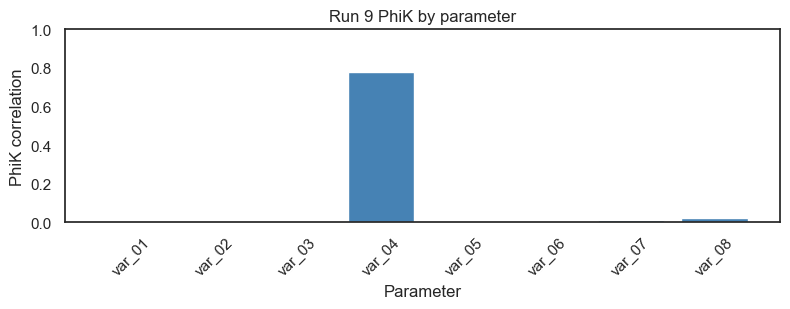

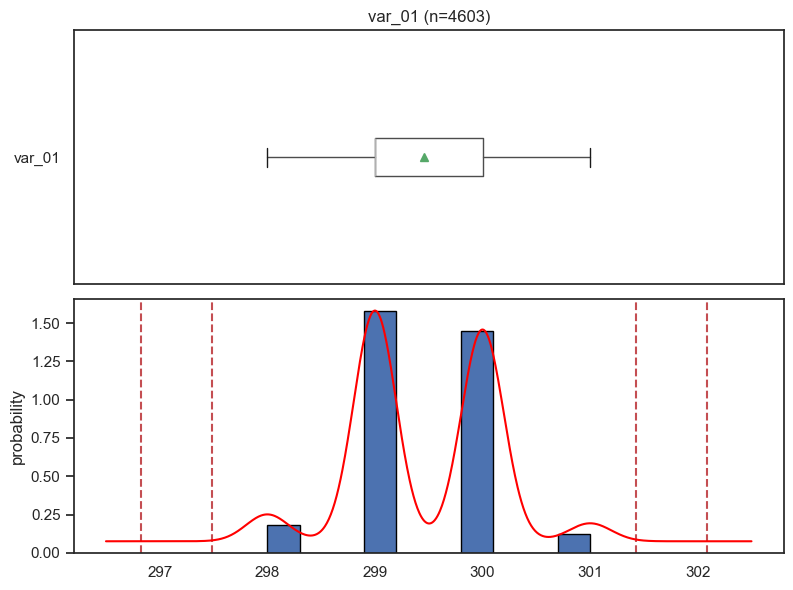

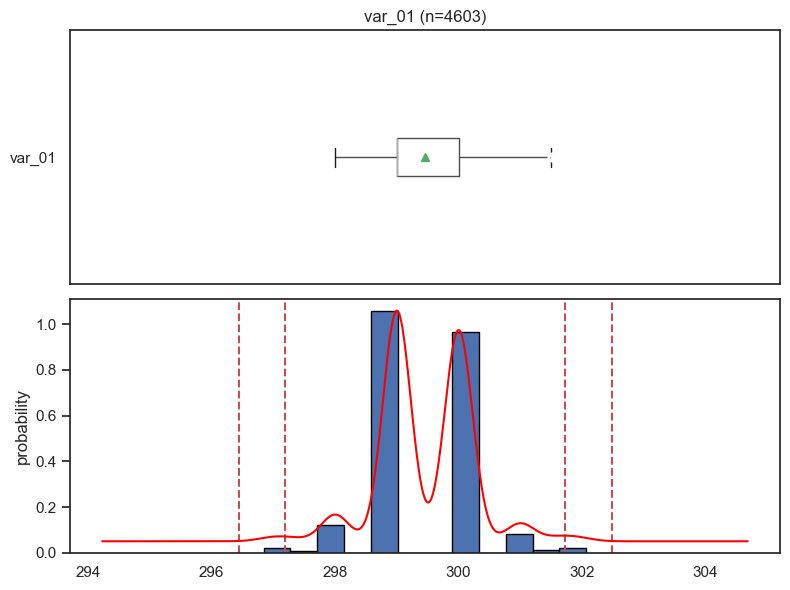

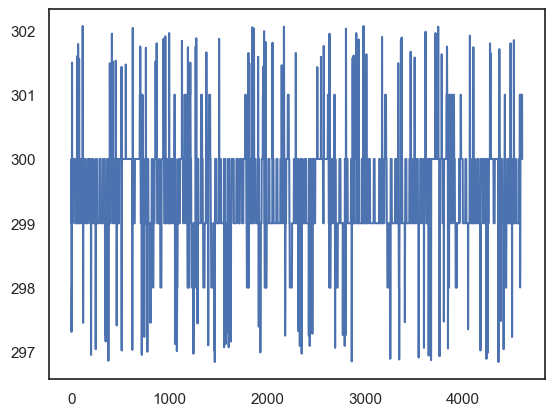

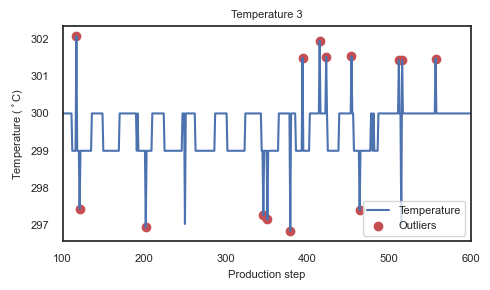

Run 10 PhiK scores


,PhiK
var_01,0.9046
var_02,0.0000
var_03,0.0000
var_04,0.0000
var_05,0.0000
var_06,0.0000
var_07,0.0000
var_08,0.0000


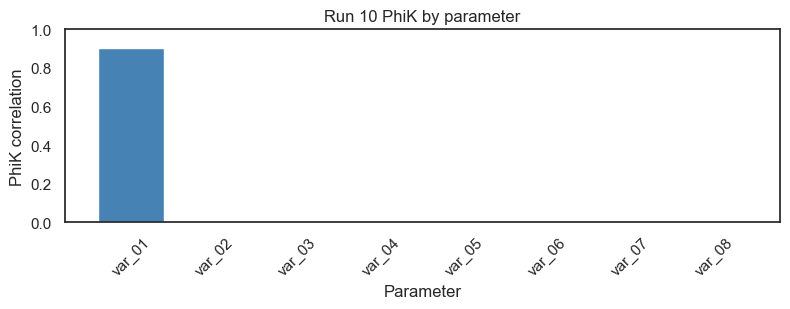

In [2]:
import random
import matplotlib.pyplot as plt
import pandas as pd
from scipy.special import softmax
import phik
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style='white')
plt.rcParams.update({'font.size': 10})
keys = ['col_027', 'col_028', 'col_029', 'col_030', 'col_031', 'col_032', 'col_033', 'col_034', 'col_label', 'col_019']


new_keys = ['var_01',
          'var_02',
          'var_03',
          'var_04',
          'var_05',
          'var_06',
          'var_07',
          'var_08',
           'var_lbl',
            'var_09'
          ]

rename_dict = {}
for index,key in enumerate(keys):
    rename_dict[key] = new_keys[index]

temp_keys = new_keys[:8]  # Temperature features only

counter,row,col=0,0,0
run_results = {}
for run in range(10):

    df = pd.read_csv("../data/batch_step_index/batch_{}.csv".format(100))
    df.rename(columns=rename_dict, inplace=True)
    df = df[new_keys]
    df[temp_keys] = df[temp_keys].astype(float)

    key = random.choice(temp_keys)

    # define dictionaries for storing the data
    temp_outlier = {}
    phi_correlations = {}
    phi_correlation_value = []
    outlier_report = {}

    temp_outlier['existing_rejections'] =  df['var_lbl'].sum() # count how many rejections exist in the dataset

    # for key in new_keys:
    outlier_generation = []

    # create the indices to correlate rejections with outliers
    # random percentage of anomalies between 0.01 and 0.03 of production
    random_numbers = random.sample(range(0,len(df)),np.random.randint(len(df)*0.01,len(df)*0.03))

    # define the boundaries for anomalies values (3σ - 4σ)
    _a = df[key].describe()
    _upper_space = [_a['mean']+3*_a['std'], _a['mean']+4*_a['std']]
    _lower_space = [_a['mean']-3*_a['std'], _a['mean']-4*_a['std']]

    for number in range(len(random_numbers)):
        #create an anomaly in both spaces (upper and lower, and randomly choose one to proceed with the dataset)

        _outlier_errors = [random.uniform(_upper_space[0], _upper_space[1]),
                           random.uniform(_lower_space[0], _lower_space[1])]

        _flag = random.randint(0,1)
        outlier_generation.append(round(_outlier_errors[_flag],2))


    # create a reporting dictionary
    temp_outlier['major_key'] = temp_keys.index(key)
    # temp_outlier['current_key'] = key
    temp_outlier['outliers'] = len(outlier_generation)
    temp_outlier['production'] =  df['var_09'].values[-1]

    before = df.copy()
    plot_distibutions(df, key, _n_bins=10)

    df.loc[random_numbers, key] = outlier_generation    # pass the created values in the dataset



    plot_distibutions(df, key, _n_bins=12)
    # mark generated outlier points as rejected samples
    df.loc[random_numbers, 'var_lbl'] = 1


    temp_outlier['enhanced_rejections'] =  df['var_lbl'].sum()
    df[key].plot()
    plt.show()


    numberofneighbors = [40,40,30,40,100,40,40,40]
    for i,key_test in enumerate(temp_keys):

        X = df[key_test].values.reshape(-1,1)
        # y_true = df['label'].values.reshape(-1,1)
        # outliers_fraction = (y_true.sum()/len(y_true))
        # print(outliers_fraction)


        # knn = KNN(n_neighbors=3, contamination=0.05, method = 'mean', radius=0.1, algorithm='ball_tree', leaf_size=1000)
        # knn.fit(X)
        # knn_pred = knn.predict(X)
        nbrs = NearestNeighbors(n_neighbors=numberofneighbors[i])
        nbrs.fit(X)
        distances, indexes = nbrs.kneighbors(X)
        # plt.figure(figsize=(15, 7))
        # plt.plot(distances.mean(axis =1))
        # plt.show()
        distances = pd.DataFrame(distances)
        distances_mean = distances.mean(axis =1)
        df['distances_{}'.format(key_test)] = distances_mean
        _b = distances_mean.describe()

        _upper_limit_b = _b['mean']+4*_b['std']
        # _lower_limit_b = _b['mean']-3*_b['std']
        outlier_index = np.where((distances_mean >= _upper_limit_b))
        outlier_values = df.iloc[outlier_index]

        if key_test == key:
            fig = plt.figure(figsize=(5,3))
            plt.title('Temperature 3', fontsize=8)
            plt.plot(df[key_test],  color = "b")
            # plot outlier values
            plt.scatter(outlier_values.index, outlier_values[key_test], color = "r")
            plt.legend(['Temperature', 'Outliers'], fontsize=8)
            plt.ylabel('Temperature ($^\circ$C)', fontsize=8)
            plt.xlabel('Production step', fontsize=8)
            plt.xlim([100,600])
            plt.tick_params(axis='both', which='major', labelsize=8)
            plt.tight_layout()
            # plt.savefig('/plots/iterations/outliers.png', dpi=300)
            plt.show()



        pred_col = 'predictions_{}'.format(key_test)
        df[pred_col] = np.zeros(len(df), dtype=int)
        df.loc[outlier_values.index, pred_col] = 1
        if len(outlier_values) == 0:
            phi_correlation_value.append(0)
            continue
    #
    #         # df_temp = pd.DataFrame(list(zip(df['label'].values,knn_pred)),columns=['labels', 'predictions'])
    #         #
        if df['var_lbl'].nunique() < 2 or df[pred_col].nunique() < 2:
            phi_correlation_value.append(0)
            continue
        cols = ['var_lbl', pred_col]
        phi_cor_value = df[cols].global_phik(interval_cols=[])

        phi_correlation_value.append(phi_cor_value[0][0][0])

        outlier_report[key] =temp_outlier
    run_results[run] = phi_correlation_value
    display_run_phik(run, phi_correlation_value, temp_keys, show_plot=True)

results = normalize_run_results(run_results, temp_keys)


In [3]:
# Full results table
results = normalize_run_results(run_results, temp_keys)
print('results shape:', results.shape)
display(results.round(4))

results shape: (10, 8)


,var_01,var_02,var_03,var_04,var_05,var_06,var_07,var_08
Run 1,0.0000,0.0000,0.8100,0.0000,0.0,0.0,0.0000,0.0231
Run 2,0.0000,0.0000,0.0238,0.0000,0.0,0.0,0.7990,0.0214
Run 3,0.0000,0.0000,0.0000,0.7491,0.0,0.0,0.0578,0.0597
Run 4,0.0000,0.9003,0.0000,0.0000,0.0,0.0,0.0000,0.0000
Run 5,0.0000,0.8824,0.0000,0.0000,0.0,0.0,0.0000,0.0860
Run 6,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.0000,0.7611
Run 7,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.8865,0.0544
Run 8,0.0000,0.0000,0.0000,0.0000,0.0,0.0,0.8782,0.0162
Run 9,0.0000,0.0000,0.0000,0.7815,0.0,0.0,0.0129,0.0201
Run 10,0.9046,0.0000,0.0000,0.0000,0.0,0.0,0.0000,0.0000


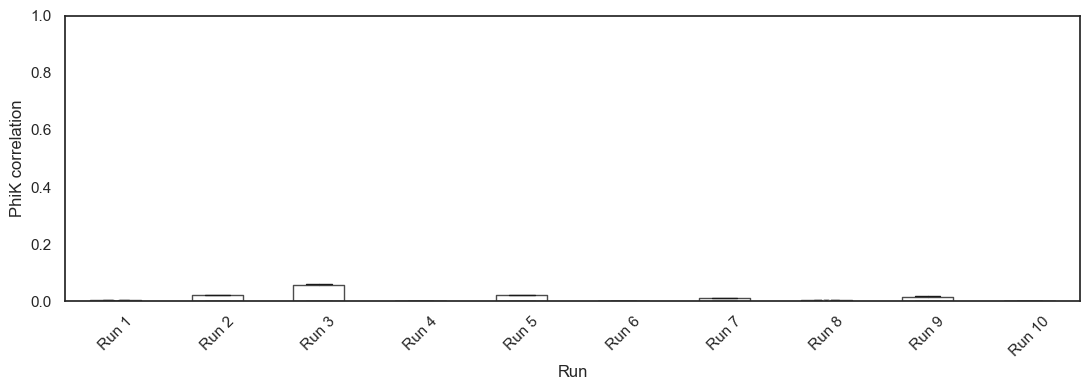

In [4]:

if results.shape[0] < 1 or results.shape[1] < 2:
    raise ValueError(f'Expected table with multiple temperature columns, got shape {results.shape}. Re-run the simulation cell first.')
run_boxplot_data = results.T
ax = run_boxplot_data.boxplot(figsize=(11, 4), grid=False, rot=45)
ax.set_xlabel('Run')
ax.set_ylabel('PhiK correlation')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()


In [5]:
results.T.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
Run 1,0.104140,0.285344,0.0,0.810049
Run 2,0.105526,0.280402,0.0,0.799023
Run 3,0.108327,0.260272,0.0,0.749109
Run 4,0.112533,0.318292,0.0,0.900265
Run 5,0.121051,0.309114,0.0,0.882438
Run 6,0.095140,0.269097,0.0,0.761122
Run 7,0.117616,0.311267,0.0,0.886520
Run 8,0.111792,0.309721,0.0,0.878184
Run 9,0.101804,0.274747,0.0,0.781503
Run 10,0.113070,0.319811,0.0,0.904562
